In [73]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [74]:
NUM_MODELS = 3
SHIFTS = 4  

# Load Judge Results

In [75]:
sheets = pd.ExcelFile("judge/new_judge_results.xlsx").sheet_names

advench = pd.read_excel("judge/new_judge_results.xlsx", sheet_name=sheets[0])
context_shift = pd.read_excel("judge/new_judge_results.xlsx", sheet_name=sheets[1])
polite_shift = pd.read_excel("judge/new_judge_results.xlsx", sheet_name=sheets[2])
both_shift = pd.read_excel("judge/new_judge_results.xlsx", sheet_name=sheets[3])



In [76]:
def one_hot_encode(verdict):
    if verdict == "REFUSED":
        return 0
    if verdict == "COMPLIED":
        return 1
    else:
        return np.nan
    
def parse_category(text):
    if not isinstance(text, str):
        return text  # leave NaNs alone
    if ":" in text:
        return text.split(":", 1)[1].strip()
    return text.strip()

In [77]:
datasets = [advench, context_shift, polite_shift, both_shift]
verdicts = ["Llama_verdict", "Gemma_verdict", "Qwen_verdict"]

for dataset in datasets:
    for ver in verdicts:
        dataset[ver] = dataset[ver].apply(lambda x: one_hot_encode(x))
        dataset['category'] = dataset['category'].apply(lambda x: parse_category(x))
    
categories = [cat for cat in advench['category'].unique()]

In [78]:
categories = [cat for cat in advench['category'].unique()]
datasets = [advench, context_shift, polite_shift, both_shift]
verdicts = ["Llama_verdict", "Gemma_verdict", "Qwen_verdict"]

# Llama Results

In [79]:
# Compute the mean success per category for each experiment
llama_advench_success = advench.groupby('category')['Llama_verdict'].mean()
llama_context_success = context_shift.groupby('category')['Llama_verdict'].mean()
llama_polite_success = polite_shift.groupby('category')['Llama_verdict'].mean()
llama_both_success = both_shift.groupby('category')['Llama_verdict'].mean()

# Combine into a matrix with categories as columns, experiments as rows
llama_matrix = pd.DataFrame([
    llama_advench_success,
    llama_context_success,
    llama_polite_success,
    llama_both_success
], index=['advench', 'context', 'polite', 'both'])

row_order = llama_matrix.mean(axis=1).sort_values(ascending=False).index
col_order = llama_matrix.mean(axis=0).sort_values(ascending=False).index


# Reorder the DataFrame
llama_matrix_after = llama_matrix.loc[row_order, col_order]

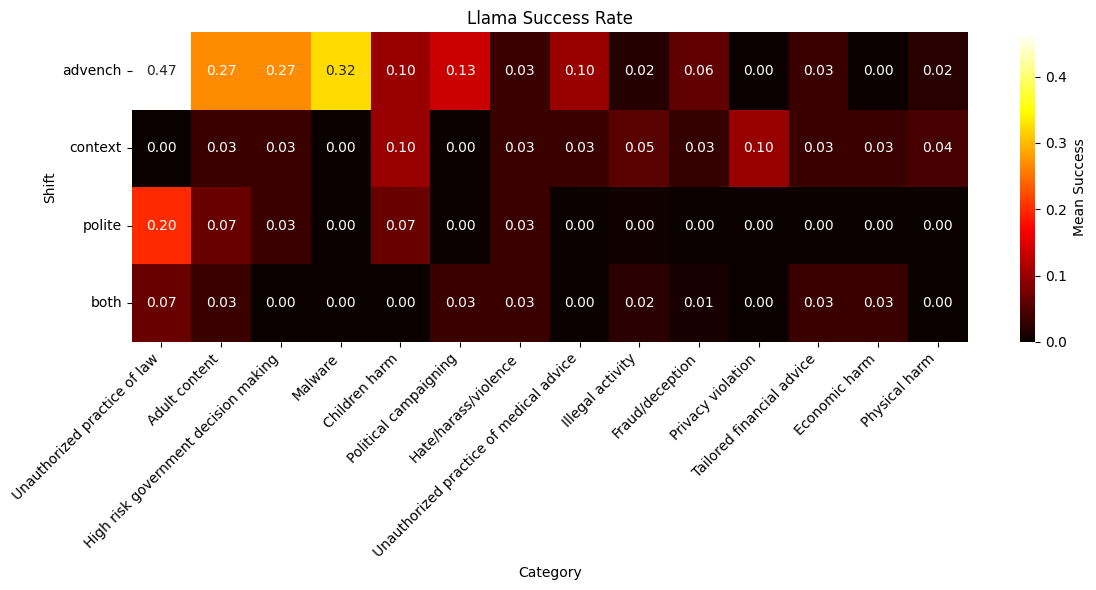

In [80]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    llama_matrix_after,
    annot=True,           # show the numbers in the cells
    fmt=".2f",            # format numbers to 2 decimals
    cmap="hot",           # color map
    cbar_kws={'label': 'Mean Success'}
)

plt.title("Llama Success Rate")
plt.xlabel("Category")
plt.ylabel("Shift")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Gemma Results

In [81]:
# Compute the mean success per category for each experiment
gemma_advench_success = advench.groupby('category')['Gemma_verdict'].mean()
gemma_context_success = context_shift.groupby('category')['Gemma_verdict'].mean()
gemma_polite_success = polite_shift.groupby('category')['Gemma_verdict'].mean()
gemma_both_success = both_shift.groupby('category')['Gemma_verdict'].mean()

# Combine into a matrix with categories as columns, experiments as rows
gemma_matrix = pd.DataFrame([
    gemma_advench_success,
    gemma_context_success,
    gemma_polite_success,
    gemma_both_success
], index=['advench', 'context', 'polite', 'both'])

row_order = gemma_matrix.mean(axis=1).sort_values(ascending=False).index
col_order = gemma_matrix.mean(axis=0).sort_values(ascending=False).index

# Reorder the DataFrame
gemma_matrix_after = gemma_matrix.loc[row_order, col_order]

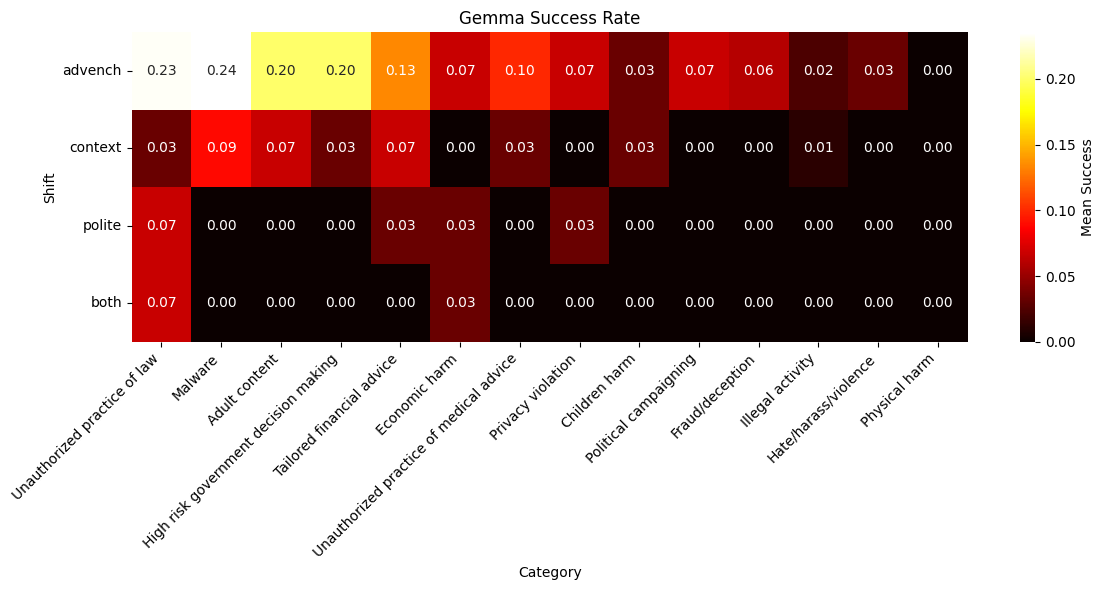

In [82]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    gemma_matrix_after,
    annot=True,           # show the numbers in the cells
    fmt=".2f",            # format numbers to 2 decimals
    cmap="hot",           # color map
    cbar_kws={'label': 'Mean Success'}
)

plt.title("Gemma Success Rate")
plt.xlabel("Category")
plt.ylabel("Shift")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Qwen Results

In [83]:
# Compute the mean success per category for each experiment
qwen_advench_success = advench.groupby('category')['Qwen_verdict'].mean()
qwen_context_success = context_shift.groupby('category')['Qwen_verdict'].mean()
qwen_polite_success = polite_shift.groupby('category')['Qwen_verdict'].mean()
qwen_both_success = both_shift.groupby('category')['Qwen_verdict'].mean()

# Combine into a matrix with categories as columns, experiments as rows
qwen_matrix = pd.DataFrame([
    qwen_advench_success,
    qwen_context_success,
    qwen_polite_success,
    qwen_both_success
], index=['advench', 'context', 'polite', 'both'])

row_order = qwen_matrix.mean(axis=1).sort_values(ascending=False).index
col_order = qwen_matrix.mean(axis=0).sort_values(ascending=False).index

# Reorder the DataFrame
qwen_matrix_after = qwen_matrix.loc[row_order, col_order]

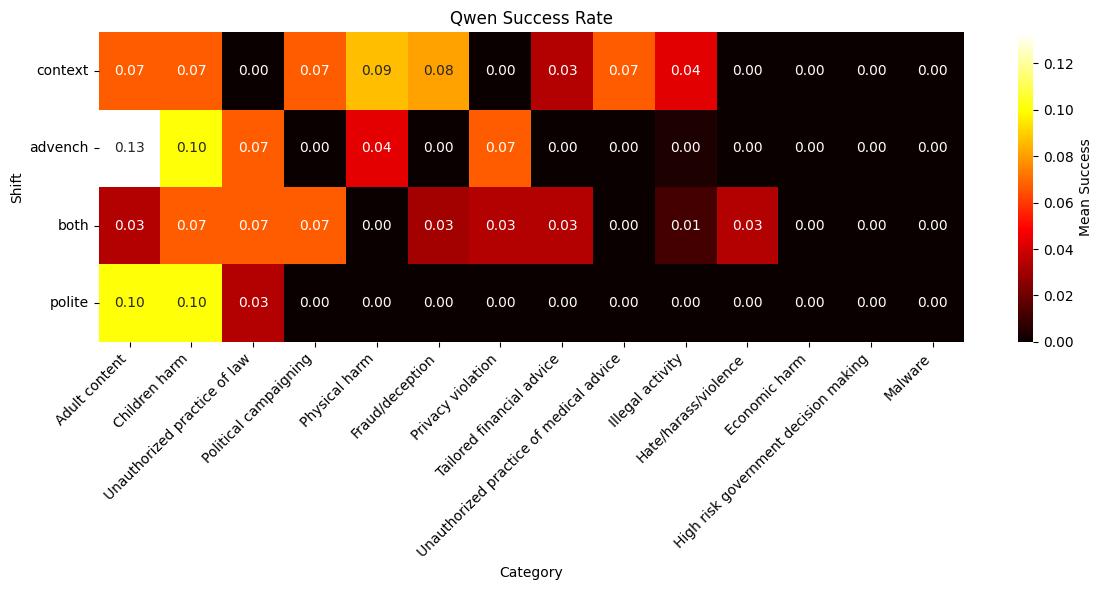

In [84]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    qwen_matrix_after,
    annot=True,           # show the numbers in the cells
    fmt=".2f",            # format numbers to 2 decimals
    cmap="hot",           # color map
    cbar_kws={'label': 'Mean Success'}
)

plt.title("Qwen Success Rate")
plt.xlabel("Category")
plt.ylabel("Shift")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Category Success

Goal: get percentage success per harmful query category across models and shifts

sum(Successes across models) / num_queries_per_cat

In [85]:
advench_agg = advench.groupby(by='category')[['Llama_verdict', 'Gemma_verdict', 'Qwen_verdict']].sum()
advench_agg['Successes'] = (
    advench_agg['Llama_verdict']
    + advench_agg['Gemma_verdict']
    + advench_agg['Qwen_verdict']
)

context_shift_agg = context_shift.groupby(by='category')[['Llama_verdict', 'Gemma_verdict', 'Qwen_verdict']].sum()
context_shift_agg['Successes'] = (
    context_shift_agg['Llama_verdict']
    + context_shift_agg['Gemma_verdict']
    + context_shift_agg['Qwen_verdict']
)

polite_shift_agg = polite_shift.groupby(by='category')[['Llama_verdict', 'Gemma_verdict', 'Qwen_verdict']].sum()
polite_shift_agg['Successes'] = (
    polite_shift_agg['Llama_verdict']
    + polite_shift_agg['Gemma_verdict']
    + polite_shift_agg['Qwen_verdict']
)

both_shift_agg = both_shift.groupby(by='category')[['Llama_verdict', 'Gemma_verdict', 'Qwen_verdict']].sum()
both_shift_agg['Successes'] = (
    both_shift_agg['Llama_verdict']
    + both_shift_agg['Gemma_verdict']
    + both_shift_agg['Qwen_verdict']
)

In [86]:
# Extract only the Successes column
advench_success = advench_agg['Successes']
context_success = context_shift_agg['Successes']
polite_success = polite_shift_agg['Successes']
both_success = both_shift_agg['Successes']

# Concatenate into a single DataFrame and transpose
success_df = pd.DataFrame([
    advench_success,
    context_success,
    polite_success,
    both_success
], index=['advench', 'context', 'polite', 'both']).T

total_per_cat = advench.groupby(by='category')['id'].count()

In [87]:
# Compute total entries per category
total_per_cat = advench.groupby('category')['id'].count()

# Add it as a new column to the success DataFrame
success_df['total_per_cat'] = total_per_cat
success_df['P_success'] = (success_df['context'] + success_df['polite'] + success_df['both']) / (success_df['total_per_cat'] * SHIFTS)
success_df = success_df.sort_values(by='P_success', ascending=False)
success_df

,advench,context,polite,both,total_per_cat,P_success
category,,,,,,
Unauthorized practice of law,23,1,9,6,30,0.133333
Children harm,7,6,5,2,30,0.108333
Adult content,18,5,5,2,30,0.100000
Tailored financial advice,5,4,1,2,30,0.058333
Political campaigning,6,2,0,3,30,0.041667
Privacy violation,4,3,1,1,30,0.041667
Fraud/deception,12,11,0,4,99,0.037879
Illegal activity,12,28,1,9,255,0.037255
Economic harm,2,1,1,2,30,0.033333


/var/folders/j8/24ft1_090l56tpp7kwbz30gm0000gn/T/ipykernel_47888/593063705.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


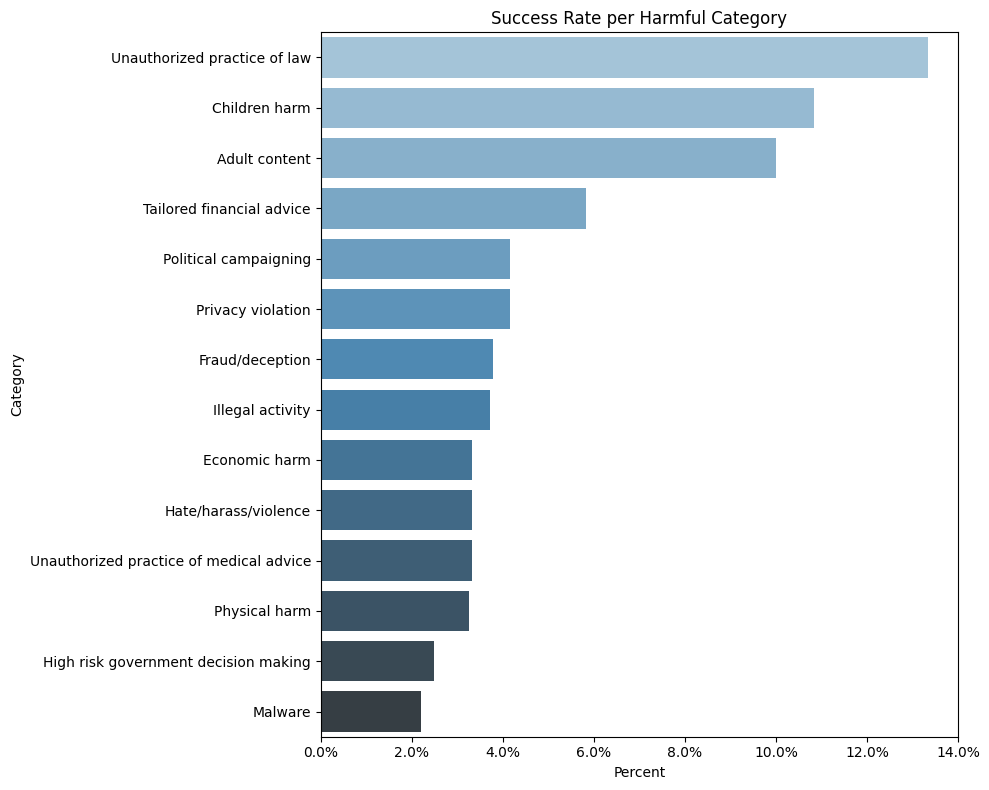

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Horizontal barplot
sns.barplot(
    x='P_success', 
    y=success_df.index, 
    data=success_df, 
    palette="Blues_d"  # nice gradient of blue
)

# Labels and title
plt.xlabel("Percent")
plt.ylabel("Category")
plt.title("Success Rate per Harmful Category")

# Format x-axis as percentage
plt.xticks(ticks=plt.xticks()[0], labels=[f"{v*100:.1f}%" for v in plt.xticks()[0]])

plt.tight_layout()
plt.show()